# **PONTIFICIA UNIVERSIDAD JAVERIANA**
## **Procesamiento de alto volumen de datos**
**Fecha:** 7 de Abril del 2026

**Autor:** Grupo Sigma

**Tema:** Proyecto de Big Data

**Objetivo:** 
- Entender la importancia del uso de herramientas de Big Data en entornos empresariales, a fin de poder solucionar preguntas de negocio.
- Entender el paso a paso de un proyecto de procesamiento de datos para la generación de hallazgos de valor basado en la metodología CRISP-DM.
- Documentar la implementación de un cluster como infraestructura de procesamiento de grandes volúmenes de datos, a través de máquinas virtuales
- Realizar procesamiento de datos aplicado a entender y mejorar los indicadores ICFES en el territorio nacional.
- Integrar conjuntos de datos territoriales, sociales y económicos con los resultados educativos nacionales.
- Realizar exploración y transformación del conjunto global de datos disponible que permita su análisis de forma correcta y sin sesgos.

**Version:** Entrega 1

### Para asegurar que el proyecto funcione correctamente con pandas, matplotlib, seaborn y findspark, ejecutar el siguiente comando desde la raíz del proyecto
```bash
pip install -r requirements.txt
```

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para graficar y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar
import scipy.stats as stats     # -> Para pruebas estadisticas

In [2]:
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql.functions import *             # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos
import pyspark.sql.functions as F               # -> Para funciones de manipulacion de columnas (alias)
from pyspark.ml.feature import VectorAssembler  # -> Para construcción de vectores
from pyspark.ml.stat import Correlation         # -> Para calculo de correlaciones

In [3]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 21:09:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/08 21:09:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/08 21:09:02 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/08 21:09:02 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


### Actividades a realizar

- Lectura de data
- Descripción de los datos
- Exploración de los datos
- Reporte de calidad
- Planteamiento de preguntas investigativas
- Limpieza, filtro y transformaciones iniciales

## **Lectura de data**

In [4]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El archivo tiene dos filas de encabezado: la primera contiene los grupos de índices
## y la segunda los nombres reales de las columnas. Se leen las 28 columnas por posición.
NombresNuevos = [
    'ID', 'COD_DPTO', 'DEPARTAMENTO', 'DIVIPOLA', 'MUNICIPIO', 'TIPO_MUNICIPIO',
    'AREA_AMENAZADA_HA', 'PCT_AREA_AMENAZADA',
    'POBLACION_EXPUESTA', 'PCT_POB_EXPUESTA',
    'IPM', 'IR_E',
    'VALOR_AGREGADO_PERCAPITA', 'PCT_POB_CABECERA', 'DENSIDAD_EMPRESARIAL',
    'COMP_SOCIOECONOMICO', 'INGRESOS_TRIBUTARIOS_PERCAPITA', 'COMP_FINANCIERO',
    'CMGRD', 'PMGRD', 'EMRE',
    'NUM_HERRAMIENTAS_GRD', 'INVERSION_GRD_PERCAPITA', 'COMP_GESTION_RIESGO',
    'IC_E', 'GRUPO_CAPACIDAD', 'DISTANCIA_EUCLIDIANA', 'IMRC_E'
]

dfPy00_raw = sparkSigma.read.format("csv") \
    .option("header", "false") \
    .option("encoding", "ISO-8859-1") \
    .load("../data/IMRC-BASE-DE-DATOS-2024_Hoja_1.csv")

dfPy00 = dfPy00_raw.filter(
    F.col("_c0").isNotNull() &
    ~F.col("_c0").rlike("^(ID|MUNICIPIO)")
).toDF(*NombresNuevos)

dfPy00.show(5, truncate=True)
print(f"Total de registros cargados: {dfPy00.count()}")

26/04/08 21:09:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+----------------+-----+-----+------------------------+----------------+--------------------+-------------------+------------------------------+---------------+------+---------+------------+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
|                  ID|            COD_DPTO|        DEPARTAMENTO|            DIVIPOLA|           MUNICIPIO|      TIPO_MUNICIPIO|   AREA_AMENAZADA_HA|PCT_AREA_AMENAZADA|POBLACION_EXPUESTA|PCT_POB_EXPUESTA|  IPM| IR_E|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|COMP_SOCIOECONOMICO|INGRESOS_TRIBUTARIOS_PERCAPITA|COMP_FINANCIERO| CMGRD|    PMGRD|        EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_E|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_E|
+-------------------

[Stage 2:>                                                          (0 + 1) / 1]

Total de registros cargados: 1122


## **Descripción de los datos**

In [5]:
dfPy00.printSchema()

root
 |-- ID: string (nullable = true)
 |-- COD_DPTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- DIVIPOLA: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- TIPO_MUNICIPIO: string (nullable = true)
 |-- AREA_AMENAZADA_HA: string (nullable = true)
 |-- PCT_AREA_AMENAZADA: string (nullable = true)
 |-- POBLACION_EXPUESTA: string (nullable = true)
 |-- PCT_POB_EXPUESTA: string (nullable = true)
 |-- IPM: string (nullable = true)
 |-- IR_E: string (nullable = true)
 |-- VALOR_AGREGADO_PERCAPITA: string (nullable = true)
 |-- PCT_POB_CABECERA: string (nullable = true)
 |-- DENSIDAD_EMPRESARIAL: string (nullable = true)
 |-- COMP_SOCIOECONOMICO: string (nullable = true)
 |-- INGRESOS_TRIBUTARIOS_PERCAPITA: string (nullable = true)
 |-- COMP_FINANCIERO: string (nullable = true)
 |-- CMGRD: string (nullable = true)
 |-- PMGRD: string (nullable = true)
 |-- EMRE: string (nullable = true)
 |-- NUM_HERRAMIENTAS_GRD: string (nullable = true)
 |--

Este conjunto de datos corresponde al **Índice Municipal de Riesgo de Desastres Ajustado por Capacidades (IMRC) 2024** para el fenómeno de **Exceso de Lluvias**, publicado por la Unidad Nacional para la Gestión del Riesgo de Desastres (UNGRD). Su propósito es caracterizar el nivel de riesgo de cada municipio colombiano frente a eventos de inundación y exceso hídrico, combinando indicadores de amenaza, exposición, vulnerabilidad y capacidad institucional para la gestión del riesgo. En el contexto del proyecto, este dataset permite analizar si los entornos de alto riesgo de desastre afectan el rendimiento de los estudiantes en las pruebas ICFES.

El dataset tiene una estructura jerárquica de tres grandes bloques de variables:

**Bloque 1 – Índice de Riesgo de Desastres (IR_E):** Mide la amenaza física y la exposición de la población al exceso de lluvias.
- ***ID***: Identificador numérico del registro.
- ***Cód DPTO***: Código del departamento (DIVIPOLA).
- ***Departamento***: Nombre del departamento.
- ***DIVIPOLA***: Código único del municipio según el DANE.
- ***Municipio***: Nombre del municipio.
- ***Tipo de Municipio***: Categoría administrativa (Municipio, Área no municipalizada, Isla).
- ***Área amenazada Exceso (AA) has***: Hectáreas del municipio clasificadas bajo amenaza de exceso de lluvias.
- ***%AA***: Porcentaje del área total del municipio en zona de amenaza.
- ***Población Expuesta a exceso (PE)***: Número de habitantes en zonas de amenaza.
- ***%PE***: Porcentaje de la población total expuesta.
- ***Vulnerabilidad social (% IPM)***: Índice de Pobreza Multidimensional del municipio (proxy de vulnerabilidad).
- ***Índice de Riesgo de Desastres Exceso (IR_E)***: Índice compuesto de riesgo (0–100).

**Bloque 2 – Índice de Capacidades (IC_E):** Mide la capacidad institucional y financiera del municipio para gestionar el riesgo.
- ***Valor Agregado per cápita***: PIB municipal promedio per cápita 2016–2019 (precios constantes 2019).
- ***Porcentaje Población en Cabecera 2019***: Grado de urbanización.
- ***Densidad Empresarial (2019)***: Número de empresas por cada 10,000 habitantes.
- ***Componente socioeconómico***: Índice sintético 0–1 del componente económico.
- ***Ingresos tributarios y no tributarios per cápita***: Promedio de recaudo fiscal municipal 2016–2019.
- ***Componente financiera***: Índice sintético 0–1 de la capacidad financiera.
- ***CMGRD (2016–2021)***: Existencia del Consejo Municipal de Gestión del Riesgo de Desastres.
- ***PMGRD 2019–2021***: Estado del Plan Municipal de Gestión del Riesgo.
- ***EMRE 2019–2021***: Estado de la Estrategia Municipal de Respuesta a Emergencias.
- ***No. herramientas GRD***: Número de herramientas institucionales (0, 1 o 2).
- ***Inversión Promedio GRD per cápita***: Inversión municipal en gestión del riesgo 2016–2019.
- ***Componente gestión del riesgo***: Índice sintético 0–1 del componente institucional.
- ***Índice de Capacidades – Exceso (IC_E)***: Índice compuesto de capacidades (0–1).

**Bloque 3 – Índice Ajustado (IMRC_E):** Resultado final que combina riesgo y capacidades.
- ***Grupo de Capacidad (GC)***: Clasificación del municipio en quintiles de capacidad (G1–G4) o categoría especial (C).
- ***Distancia Euclidiana***: Distancia al centroide del grupo de capacidad.
- ***IMRC_E***: Índice de Riesgo Ajustado por Capacidades (0–100). Variable objetivo del dataset.

| Variable | Tipo | Descripción | Ejemplo |
| :--- | :--- | :--- | :--- |
| `DIVIPOLA` | **String** | Código único municipal DANE | `"05001"` |
| `Municipio` | **String** | Nombre del municipio | `"MEDELLÍN"` |
| `IR_E` | **Double** | Índice de riesgo de desastres (0–100) | `5.65` |
| `IC_E` | **Double** | Índice de capacidades (0–1) | `0.71` |
| `IMRC_E` | **Double** | Índice ajustado por capacidades (0–100) | `31.9` |
| `GC` | **String** | Grupo de capacidad institucional | `"C"` |

### **Diagnóstico y tratamiento de datos sobre PySpark**

- **1** Cambio de nombre de columnas
- **2** Tipos y coherencia de datos
- **3** Identificación y tratamiento de nulos

### 1 - Cambio de nombre de columnas

In [6]:
dfPy00.columns

['ID',
 'COD_DPTO',
 'DEPARTAMENTO',
 'DIVIPOLA',
 'MUNICIPIO',
 'TIPO_MUNICIPIO',
 'AREA_AMENAZADA_HA',
 'PCT_AREA_AMENAZADA',
 'POBLACION_EXPUESTA',
 'PCT_POB_EXPUESTA',
 'IPM',
 'IR_E',
 'VALOR_AGREGADO_PERCAPITA',
 'PCT_POB_CABECERA',
 'DENSIDAD_EMPRESARIAL',
 'COMP_SOCIOECONOMICO',
 'INGRESOS_TRIBUTARIOS_PERCAPITA',
 'COMP_FINANCIERO',
 'CMGRD',
 'PMGRD',
 'EMRE',
 'NUM_HERRAMIENTAS_GRD',
 'INVERSION_GRD_PERCAPITA',
 'COMP_GESTION_RIESGO',
 'IC_E',
 'GRUPO_CAPACIDAD',
 'DISTANCIA_EUCLIDIANA',
 'IMRC_E']

In [7]:
dfPy01 = dfPy00
dfPy01.columns

['ID',
 'COD_DPTO',
 'DEPARTAMENTO',
 'DIVIPOLA',
 'MUNICIPIO',
 'TIPO_MUNICIPIO',
 'AREA_AMENAZADA_HA',
 'PCT_AREA_AMENAZADA',
 'POBLACION_EXPUESTA',
 'PCT_POB_EXPUESTA',
 'IPM',
 'IR_E',
 'VALOR_AGREGADO_PERCAPITA',
 'PCT_POB_CABECERA',
 'DENSIDAD_EMPRESARIAL',
 'COMP_SOCIOECONOMICO',
 'INGRESOS_TRIBUTARIOS_PERCAPITA',
 'COMP_FINANCIERO',
 'CMGRD',
 'PMGRD',
 'EMRE',
 'NUM_HERRAMIENTAS_GRD',
 'INVERSION_GRD_PERCAPITA',
 'COMP_GESTION_RIESGO',
 'IC_E',
 'GRUPO_CAPACIDAD',
 'DISTANCIA_EUCLIDIANA',
 'IMRC_E']

In [8]:
dfPy01.show(5, truncate=True)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+----------------+-----+-----+------------------------+----------------+--------------------+-------------------+------------------------------+---------------+------+---------+------------+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
|                  ID|            COD_DPTO|        DEPARTAMENTO|            DIVIPOLA|           MUNICIPIO|      TIPO_MUNICIPIO|   AREA_AMENAZADA_HA|PCT_AREA_AMENAZADA|POBLACION_EXPUESTA|PCT_POB_EXPUESTA|  IPM| IR_E|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|COMP_SOCIOECONOMICO|INGRESOS_TRIBUTARIOS_PERCAPITA|COMP_FINANCIERO| CMGRD|    PMGRD|        EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_E|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_E|
+-------------------

### 2 - Tipos y coherencia de datos

In [9]:
dfPy01.printSchema()

root
 |-- ID: string (nullable = true)
 |-- COD_DPTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- DIVIPOLA: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- TIPO_MUNICIPIO: string (nullable = true)
 |-- AREA_AMENAZADA_HA: string (nullable = true)
 |-- PCT_AREA_AMENAZADA: string (nullable = true)
 |-- POBLACION_EXPUESTA: string (nullable = true)
 |-- PCT_POB_EXPUESTA: string (nullable = true)
 |-- IPM: string (nullable = true)
 |-- IR_E: string (nullable = true)
 |-- VALOR_AGREGADO_PERCAPITA: string (nullable = true)
 |-- PCT_POB_CABECERA: string (nullable = true)
 |-- DENSIDAD_EMPRESARIAL: string (nullable = true)
 |-- COMP_SOCIOECONOMICO: string (nullable = true)
 |-- INGRESOS_TRIBUTARIOS_PERCAPITA: string (nullable = true)
 |-- COMP_FINANCIERO: string (nullable = true)
 |-- CMGRD: string (nullable = true)
 |-- PMGRD: string (nullable = true)
 |-- EMRE: string (nullable = true)
 |-- NUM_HERRAMIENTAS_GRD: string (nullable = true)
 |--

In [10]:
dfPy02 = dfPy01

columnas_double = [
    'AREA_AMENAZADA_HA', 'PCT_AREA_AMENAZADA',
    'POBLACION_EXPUESTA', 'PCT_POB_EXPUESTA',
    'IPM', 'IR_E',
    'PCT_POB_CABECERA', 'DENSIDAD_EMPRESARIAL',
    'COMP_SOCIOECONOMICO', 'COMP_FINANCIERO',
    'COMP_GESTION_RIESGO', 'IC_E',
    'DISTANCIA_EUCLIDIANA', 'IMRC_E'
]
for c in columnas_double:
    dfPy02 = dfPy02.withColumn(c, F.col(c).cast(DoubleType()))

columnas_moneda = ['VALOR_AGREGADO_PERCAPITA', 'INGRESOS_TRIBUTARIOS_PERCAPITA', 'INVERSION_GRD_PERCAPITA']
for c in columnas_moneda:
    dfPy02 = dfPy02.withColumn(c,
        F.regexp_replace(F.col(c), r'[\$,\s]', '').cast(DoubleType())
    )

dfPy02 = dfPy02.withColumn('NUM_HERRAMIENTAS_GRD', F.col('NUM_HERRAMIENTAS_GRD').cast(IntegerType()))

cols_texto = ['CMGRD', 'PMGRD', 'EMRE', 'GRUPO_CAPACIDAD', 'TIPO_MUNICIPIO', 'DEPARTAMENTO', 'MUNICIPIO']
for c in cols_texto:
    dfPy02 = dfPy02.withColumn(c, F.upper(F.trim(F.col(c))))

dfPy02 = dfPy02.withColumn('CMGRD',
    F.when(F.col('CMGRD').isin('CREADO', 'CREADO '), 'CREADO').otherwise(F.col('CMGRD')))
dfPy02 = dfPy02.withColumn('PMGRD',
    F.when(F.col('PMGRD') == 'NO REPORTADO', 'NO REPORTADO').otherwise(F.col('PMGRD')))
dfPy02 = dfPy02.withColumn('EMRE',
    F.when(F.col('EMRE') == 'ADOPTADA', 'ADOPTADA').otherwise(F.col('EMRE')))

dfPy02.printSchema()

root
 |-- ID: string (nullable = true)
 |-- COD_DPTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- DIVIPOLA: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- TIPO_MUNICIPIO: string (nullable = true)
 |-- AREA_AMENAZADA_HA: double (nullable = true)
 |-- PCT_AREA_AMENAZADA: double (nullable = true)
 |-- POBLACION_EXPUESTA: double (nullable = true)
 |-- PCT_POB_EXPUESTA: double (nullable = true)
 |-- IPM: double (nullable = true)
 |-- IR_E: double (nullable = true)
 |-- VALOR_AGREGADO_PERCAPITA: double (nullable = true)
 |-- PCT_POB_CABECERA: double (nullable = true)
 |-- DENSIDAD_EMPRESARIAL: double (nullable = true)
 |-- COMP_SOCIOECONOMICO: double (nullable = true)
 |-- INGRESOS_TRIBUTARIOS_PERCAPITA: double (nullable = true)
 |-- COMP_FINANCIERO: double (nullable = true)
 |-- CMGRD: string (nullable = true)
 |-- PMGRD: string (nullable = true)
 |-- EMRE: string (nullable = true)
 |-- NUM_HERRAMIENTAS_GRD: integer (nullable = true)
 |-

#### **Decisiones de tipado y normalización**

- **Variables numéricas continuas** (`IR_E`, `IC_E`, `IMRC_E`, `IPM`, porcentajes de área y población): se realiza un cast directo a `DoubleType` ya que los valores cargados desde CSV son cadenas de texto.
- **Variables monetarias** (`VALOR_AGREGADO_PERCAPITA`, `INGRESOS_TRIBUTARIOS_PERCAPITA`, `INVERSION_GRD_PERCAPITA`): se limpian previamente los caracteres `$` y `,` mediante expresión regular antes del cast a `DoubleType`.
- **NUM_HERRAMIENTAS_GRD**: variable ordinal discreta (0, 1, 2) convertida a `IntegerType`.
- **Variables categóricas** (`CMGRD`, `PMGRD`, `EMRE`, `GRUPO_CAPACIDAD`, `TIPO_MUNICIPIO`): se normalizan a mayúsculas y sin espacios. Se detectaron variantes tipográficas como `'creado'` vs `'Creado'` y `'adoptado'` vs `'Adoptado'` que se unificaron.

In [11]:
dfPy02.show(5, truncate=True)

[Stage 6:>                                                          (0 + 1) / 1]

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------------+------------------+------------------+----------------+----+-----+------------------------+----------------+--------------------+-------------------+------------------------------+---------------+------+---------+------------+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
|                  ID|            COD_DPTO|        DEPARTAMENTO|            DIVIPOLA|           MUNICIPIO|      TIPO_MUNICIPIO|AREA_AMENAZADA_HA|PCT_AREA_AMENAZADA|POBLACION_EXPUESTA|PCT_POB_EXPUESTA| IPM| IR_E|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|COMP_SOCIOECONOMICO|INGRESOS_TRIBUTARIOS_PERCAPITA|COMP_FINANCIERO| CMGRD|    PMGRD|        EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_E|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_E|
+--------------------+------

### 3 - Identificación y tratamiento de nulos

In [12]:
print('Distribución por TIPO DE MUNICIPIO:')
dfPy02.groupby('TIPO_MUNICIPIO').count().orderBy('count', ascending=False).show()

print('Distribución por GRUPO DE CAPACIDAD:')
dfPy02.groupby('GRUPO_CAPACIDAD').count().orderBy('count', ascending=False).show()

print('Distribución por CMGRD:')
dfPy02.groupby('CMGRD').count().orderBy('count', ascending=False).show()

print('Distribución por PMGRD:')
dfPy02.groupby('PMGRD').count().orderBy('count', ascending=False).show()

print('Distribución por EMRE:')
dfPy02.groupby('EMRE').count().orderBy('count', ascending=False).show()

print('Total de registros:', dfPy02.count())
print('Registros únicos (DISTINCT):', dfPy02.distinct().count())

Distribución por TIPO DE MUNICIPIO:
+--------------------+-----+
|      TIPO_MUNICIPIO|count|
+--------------------+-----+
|           MUNICIPIO| 1102|
|ÃREA NO MUNICIPA...|   18|
|DISTANCIA EUCLADIANA|    1|
|                ISLA|    1|
+--------------------+-----+

Distribución por GRUPO DE CAPACIDAD:
+---------------+-----+
|GRUPO_CAPACIDAD|count|
+---------------+-----+
|             G2|  279|
|             G1|  279|
|             G3|  277|
|             G4|  273|
|              C|   13|
|           NULL|    1|
+---------------+-----+

Distribución por CMGRD:
+------------+-----+
|       CMGRD|count|
+------------+-----+
|      CREADO|  809|
|NO REPORTADO|  312|
|        NULL|    1|
+------------+-----+

Distribución por PMGRD:
+------------+-----+
|       PMGRD|count|
+------------+-----+
|    ADOPTADO|  458|
|NO REPORTADO|  319|
|   FORMULADO|  282|
|NO FORMULADO|   62|
|        NULL|    1|
+------------+-----+

Distribución por EMRE:


+------------+-----+
|        EMRE|count|
+------------+-----+
|NO REPORTADO|  334|
|    ADOPTADA|  328|
|NO FORMULADO|  242|
|   FORMULADO|  217|
|        NULL|    1|
+------------+-----+

Total de registros: 1122


[Stage 25:>                                                         (0 + 1) / 1]

Registros únicos (DISTINCT): 1122


In [13]:
# Conteo de nulos por columna
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        if dtype in ['double', 'float']:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

dfPy02.select(count_missings(dfPy02)).show()

+---+--------+------------+--------+---------+--------------+-----------------+------------------+------------------+----------------+---+----+------------------------+----------------+--------------------+-------------------+------------------------------+---------------+-----+-----+----+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
| ID|COD_DPTO|DEPARTAMENTO|DIVIPOLA|MUNICIPIO|TIPO_MUNICIPIO|AREA_AMENAZADA_HA|PCT_AREA_AMENAZADA|POBLACION_EXPUESTA|PCT_POB_EXPUESTA|IPM|IR_E|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|COMP_SOCIOECONOMICO|INGRESOS_TRIBUTARIOS_PERCAPITA|COMP_FINANCIERO|CMGRD|PMGRD|EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_E|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_E|
+---+--------+------------+--------+---------+--------------+-----------------+------------------+------------------+----------------+---+----+------------------------+----------------+-----

In [14]:
total_registros = dfPy02.count()
print(f'Total de registros: {total_registros}')

nulos_ir = dfPy02.filter(F.col('IR_E').isNull()).count()
print(f'Nulos en IR_E: {nulos_ir} ({nulos_ir*100/total_registros:.2f}%)')

nulos_imrc = dfPy02.filter(F.col('IMRC_E').isNull()).count()
print(f'Nulos en IMRC_E: {nulos_imrc} ({nulos_imrc*100/total_registros:.2f}%)')

nulos_dist = dfPy02.filter(F.col('DISTANCIA_EUCLIDIANA').isNull()).count()
print(f'Nulos en DISTANCIA_EUCLIDIANA: {nulos_dist} ({nulos_dist*100/total_registros:.2f}%)')

nulos_tipo = dfPy02.filter(F.col('TIPO_MUNICIPIO').isNull()).count()
print(f'Nulos en TIPO_MUNICIPIO: {nulos_tipo} ({nulos_tipo*100/total_registros:.2f}%)')

Total de registros: 1122
Nulos en IR_E: 21 (1.87%)
Nulos en IMRC_E: 1 (0.09%)
Nulos en DISTANCIA_EUCLIDIANA: 19 (1.69%)
Nulos en TIPO_MUNICIPIO: 0 (0.00%)


### **Análisis de nulos**

Tras el diagnóstico de frecuencias y conteo de nulos, se identifican los siguientes hallazgos:

- **IR_E y variables de exposición** (`POBLACION_EXPUESTA`, `PCT_POB_EXPUESTA`): 21 registros nulos (~1.87%). Corresponden a municipios para los cuales no hay datos de exposición poblacional, probablemente por ser áreas no municipalizadas o islas sin censos completos. Al ser la variable de riesgo central del análisis, estos registros se eliminarán.
- **DISTANCIA_EUCLIDIANA**: 19 nulos (~1.69%). Municipios que no fueron asignados a ningún grupo de capacidad en el algoritmo de clasificación. Se tratarán como parte de la limpieza junto con los nulos de IR_E.
- **IMRC_E**: 1 nulo (~0.09%). Registro con datos generales faltantes. Se eliminará.

### **Decisiones de tratamiento**

- Eliminación de los ~21 registros con `IR_E` nulo, ya que son la variable central del análisis y representan menos del 2% del total.
- Los registros con `TIPO_MUNICIPIO` diferente a `'MUNICIPIO'` (18 áreas no municipalizadas, 1 isla y 1 fila de encabezado residual) se filtrarán para mantener comparabilidad entre unidades territoriales.

## **Exploración de los datos**

In [15]:
dfPy02.select('IR_E', 'IC_E', 'IMRC_E', 'IPM', 'PCT_AREA_AMENAZADA', 'PCT_POB_EXPUESTA').summary().show()

[Stage 49:>                                                         (0 + 1) / 1]

+-------+------------------+-------------------+------------------+-----------------+------------------+------------------+
|summary|              IR_E|               IC_E|            IMRC_E|              IPM|PCT_AREA_AMENAZADA|  PCT_POB_EXPUESTA|
+-------+------------------+-------------------+------------------+-----------------+------------------+------------------+
|  count|              1101|               1121|              1121|             1121|              1121|              1101|
|   mean| 16.56423251589465| 0.3061552185548617|47.406601248884925|41.74451382694026|49.515664585191864| 39.88713896457767|
| stddev|13.938730562927423|0.14097343022196043|10.762736273777742|17.27884929101068| 29.10040073254216|29.815220406663844|
|    min|               0.0|                0.0|               0.0|              4.5|               0.0|               0.0|
|    25%|              3.94|               0.21|              41.1|             30.2|             25.06|             11.69|
|    50%

En promedio, los municipios colombianos tienen un Índice de Riesgo de Desastres (IR_E) de 16.56 sobre 100, con una alta dispersión (desviación estándar de 13.94) que refleja la heterogeneidad territorial del riesgo. El Índice de Capacidades (IC_E) promedio es de 0.31 sobre 1, indicando que la mayoría de los municipios tienen capacidades institucionales bajas o medias. El IMRC_E ajustado promedia 47.4 puntos, evidenciando que al descontar las capacidades el riesgo efectivo se redistribuye significativamente. El IPM promedio de 41.7% confirma los altos niveles de vulnerabilidad social en los municipios del país.

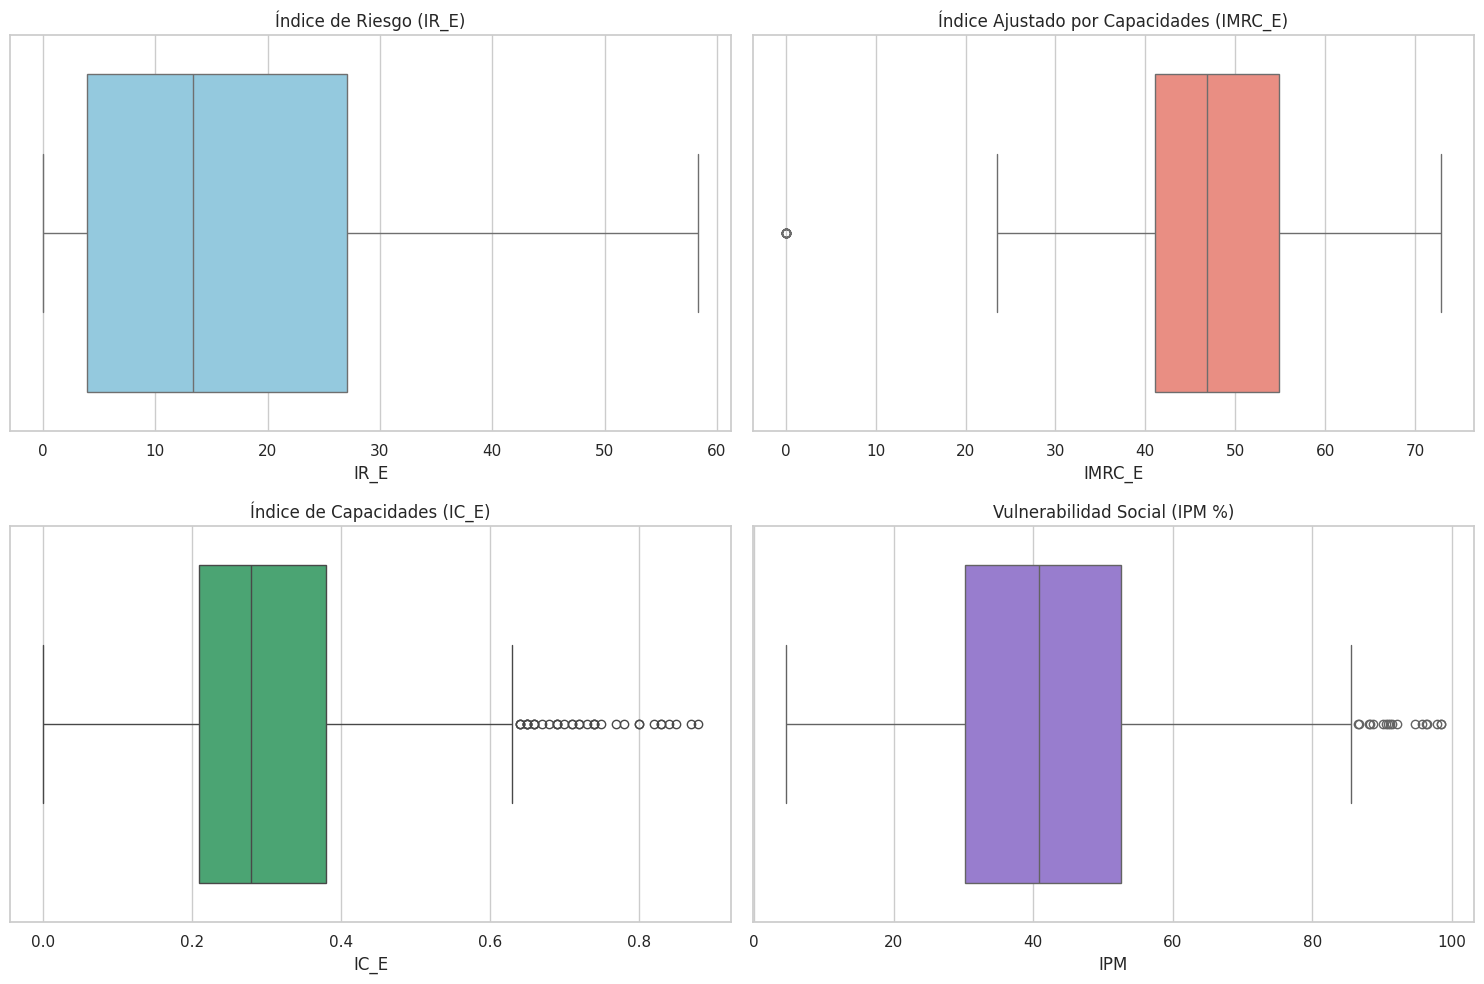

In [16]:
# Convertimos a Pandas para graficar
pdf = dfPy02.select('IR_E', 'IC_E', 'IMRC_E', 'IPM').toPandas()
sns.set_theme(style='whitegrid')

# --- FIGURA DE BOXPLOTS ---
fig_box, axes_box = plt.subplots(2, 2, figsize=(15, 10))

vars_box = [('IR_E', 'skyblue', 'Índice de Riesgo (IR_E)'),
            ('IMRC_E', 'salmon', 'Índice Ajustado por Capacidades (IMRC_E)'),
            ('IC_E', 'mediumseagreen', 'Índice de Capacidades (IC_E)'),
            ('IPM', 'mediumpurple', 'Vulnerabilidad Social (IPM %)')]

for ax, (var, color, titulo) in zip(axes_box.flat, vars_box):
    sns.boxplot(x=pdf[var].dropna(), ax=ax, color=color)
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

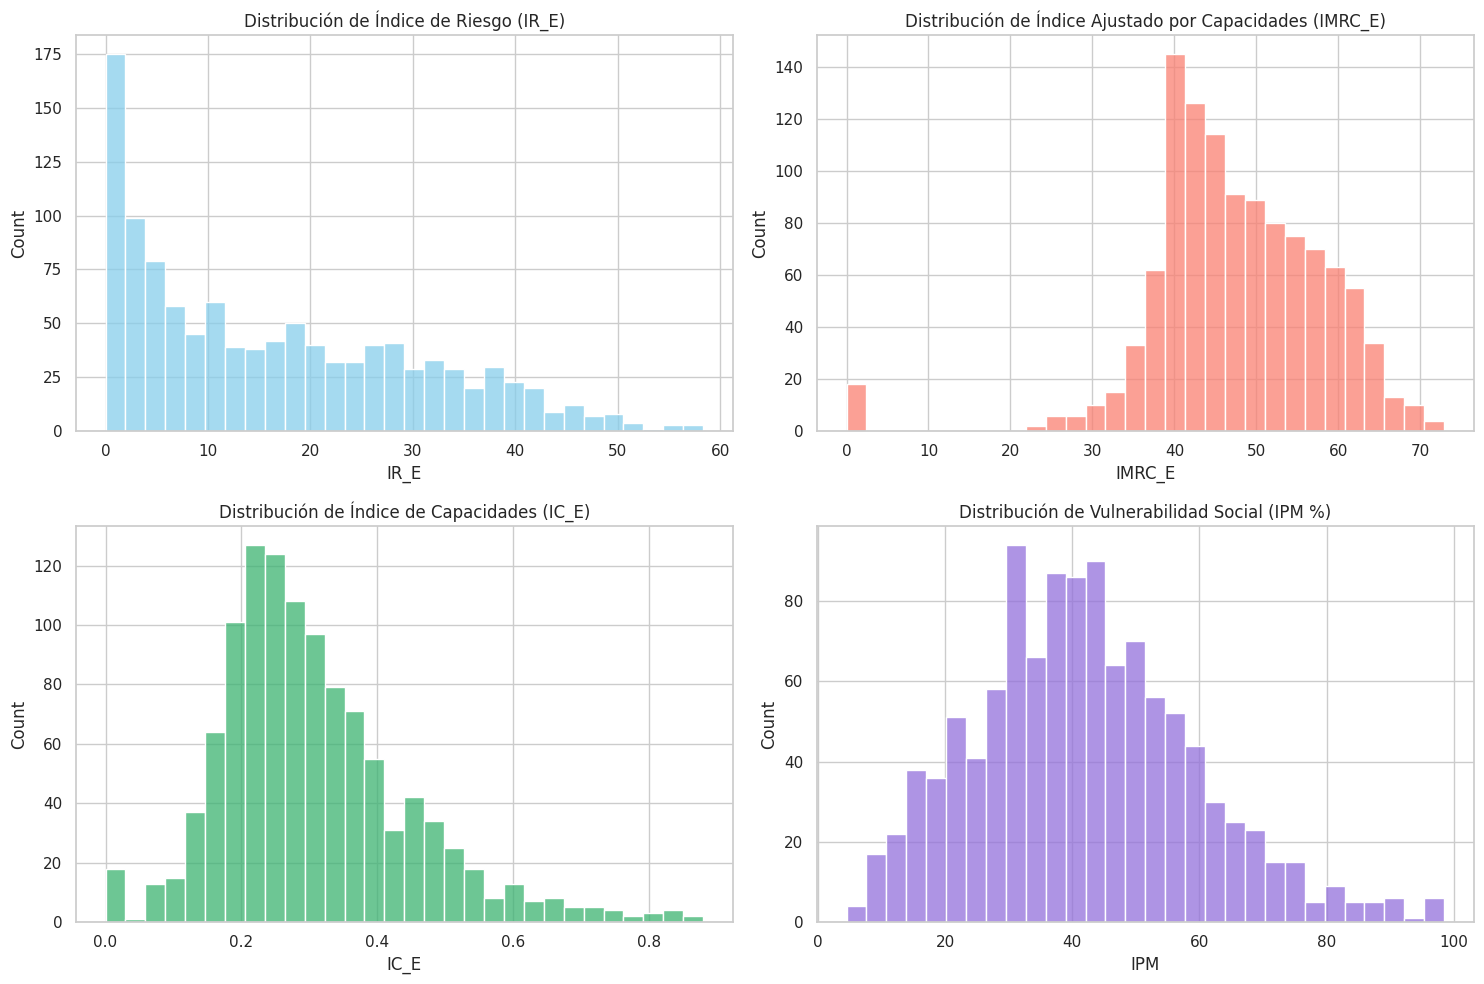

In [17]:
# --- FIGURA DE HISTOGRAMAS ---
fig_hist, axes_hist = plt.subplots(2, 2, figsize=(15, 10))

for ax, (var, color, titulo) in zip(axes_hist.flat, vars_box):
    sns.histplot(pdf[var].dropna(), ax=ax, color=color, bins=30)
    ax.set_title(f'Distribución de {titulo}')

plt.tight_layout()
plt.show()

Se observa en los boxplots e histogramas que el IR_E presenta una asimetría positiva marcada: la mayoría de los municipios tienen riesgos bajos a moderados, pero existe una cola derecha con municipios de riesgo muy elevado. El IC_E muestra una distribución más uniforme, aunque concentrada en valores bajos. El IMRC_E, al combinar riesgo y capacidades, presenta una distribución más centrada pero con varianza considerable. El IPM confirma la alta vulnerabilidad generalizada en el territorio nacional.

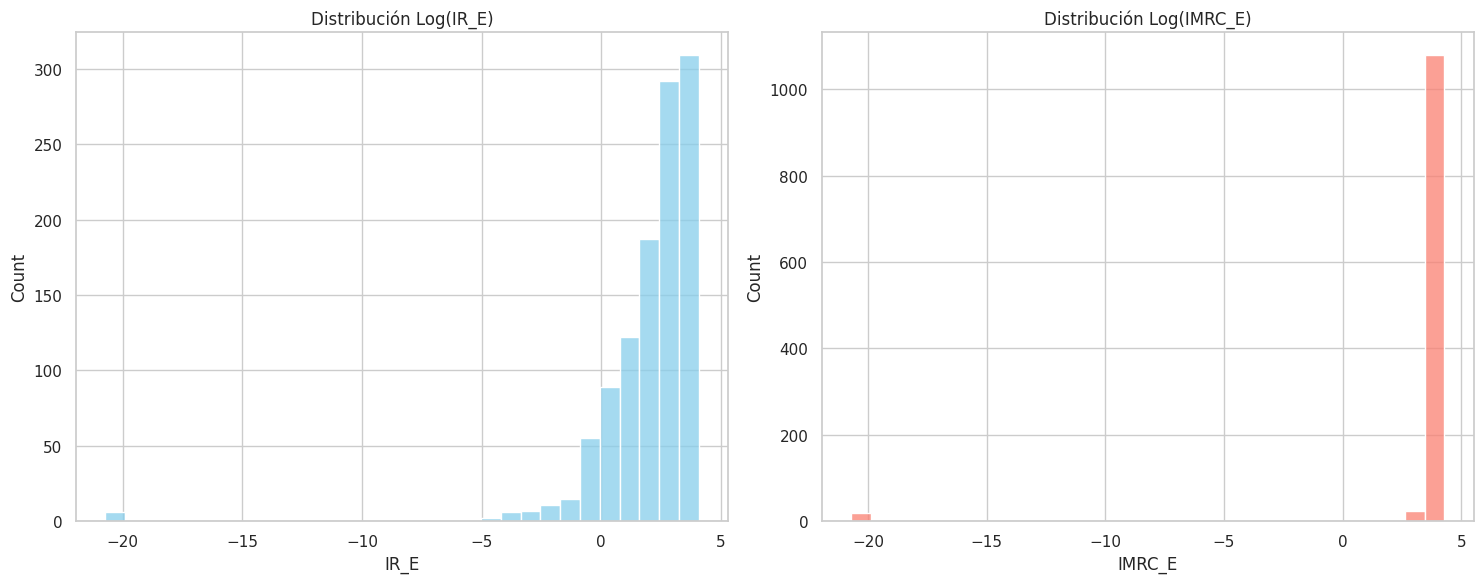

In [18]:
# Aplicamos logaritmo a IR_E para verificar log-normalidad
ir_e_log = np.log(pdf['IR_E'].dropna() + 1e-9)
imrc_log = np.log(pdf['IMRC_E'].dropna() + 1e-9)

fig_log, axes_log = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(ir_e_log, ax=axes_log[0], color='skyblue', bins=30)
axes_log[0].set_title('Distribución Log(IR_E)')
sns.histplot(imrc_log, ax=axes_log[1], color='salmon', bins=30)
axes_log[1].set_title('Distribución Log(IMRC_E)')
plt.tight_layout()
plt.show()

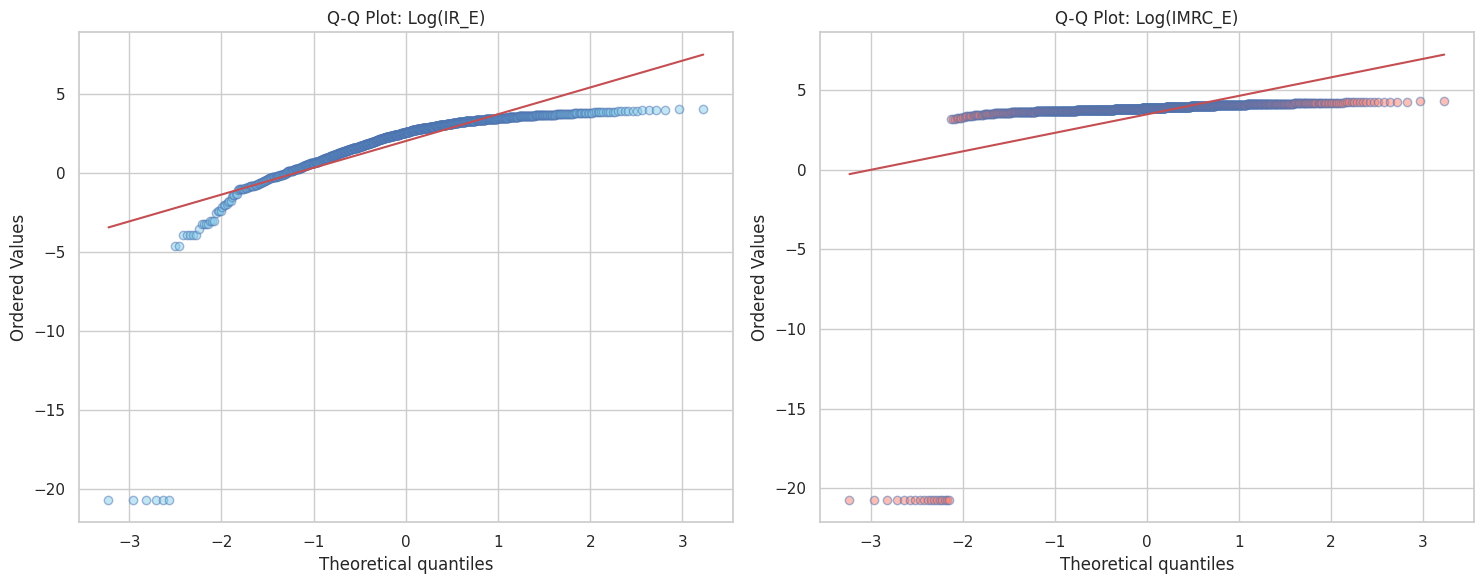

In [19]:
# QQ Plots para verificar normalidad en escala logarítmica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

stats.probplot(ir_e_log, dist='norm', plot=ax1)
ax1.set_title('Q-Q Plot: Log(IR_E)')
ax1.get_lines()[0].set_markerfacecolor('skyblue')
ax1.get_lines()[0].set_alpha(0.5)

stats.probplot(imrc_log, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot: Log(IMRC_E)')
ax2.get_lines()[0].set_markerfacecolor('salmon')
ax2.get_lines()[0].set_alpha(0.5)

plt.tight_layout()
plt.show()

In [20]:
# Municipios con riesgo cero
muns_cero_ir = dfPy02.filter(dfPy02.IR_E == 0).select('MUNICIPIO', 'DEPARTAMENTO', 'IR_E', 'IMRC_E')
print(f'Municipios con IR_E = 0: {muns_cero_ir.count()}')
muns_cero_ir.show()

muns_cero_imrc = dfPy02.filter(dfPy02.IMRC_E == 0).select('MUNICIPIO', 'DEPARTAMENTO', 'IR_E', 'IMRC_E')
print(f'Municipios con IMRC_E = 0: {muns_cero_imrc.count()}')
muns_cero_imrc.show()

Municipios con IR_E = 0: 6
+-------------------+------------+----+------+
|          MUNICIPIO|DEPARTAMENTO|IR_E|IMRC_E|
+-------------------+------------+----+------+
|   CAMPO DE LA CRUZ|  ATLÃNTICO| 0.0|  40.8|
|             CHINÃ|    CÃRDOBA| 0.0|  41.2|
|        SAN MARTÃN|        META| 0.0|  38.8|
|       LOS PALMITOS|       SUCRE| 0.0|  41.4|
|           SAMPUÃS|       SUCRE| 0.0|  41.2|
|SAN JUAN DE BETULIA|       SUCRE| 0.0|  40.9|
+-------------------+------------+----+------+

Municipios con IMRC_E = 0: 18
+------------------+------------+----+------+
|         MUNICIPIO|DEPARTAMENTO|IR_E|IMRC_E|
+------------------+------------+----+------+
|           BARANOA|  ATLÃNTICO|NULL|   0.0|
|        CANDELARIA|  ATLÃNTICO|NULL|   0.0|
|           MALAMBO|  ATLÃNTICO|NULL|   0.0|
|  PALMAR DE VARELA|  ATLÃNTICO|NULL|   0.0|
|         POLONUEVO|  ATLÃNTICO|NULL|   0.0|
|          PONEDERA|  ATLÃNTICO|NULL|   0.0|
|   PUERTO COLOMBIA|  ATLÃNTICO|NULL|   0.0|
|      SABAN

A pesar de aplicar logaritmo a los índices, los QQ plots muestran desviaciones en las colas, especialmente en la cola izquierda por los municipios con IR_E o IMRC_E igual a cero (municipios sin área amenazada registrada o sin exposición poblacional). Estos valores son atípicos estructurales que serán tratados en la fase de limpieza, filtrando los municipios con riesgo nulo para los modelos que requieran supuestos de normalidad.

In [21]:
df_temp = pdf[['IR_E', 'IMRC_E', 'IC_E', 'IPM']].dropna()

coef_ir_imrc, p_ir_imrc = stats.spearmanr(df_temp['IR_E'], df_temp['IMRC_E'])
coef_ic_imrc, p_ic_imrc = stats.spearmanr(df_temp['IC_E'], df_temp['IMRC_E'])
coef_ipm_ir, p_ipm_ir = stats.spearmanr(df_temp['IPM'], df_temp['IR_E'])

print('--- Correlaciones de Spearman ---')
print(f'IR_E  vs IMRC_E : rho={coef_ir_imrc:.4f}, p={p_ir_imrc:.2e}')
print(f'IC_E  vs IMRC_E : rho={coef_ic_imrc:.4f}, p={p_ic_imrc:.2e}')
print(f'IPM   vs IR_E   : rho={coef_ipm_ir:.4f}, p={p_ipm_ir:.2e}')

--- Correlaciones de Spearman ---
IR_E  vs IMRC_E : rho=0.9443, p=0.00e+00
IC_E  vs IMRC_E : rho=-0.5553, p=4.43e-90
IPM   vs IR_E   : rho=0.3711, p=2.78e-37


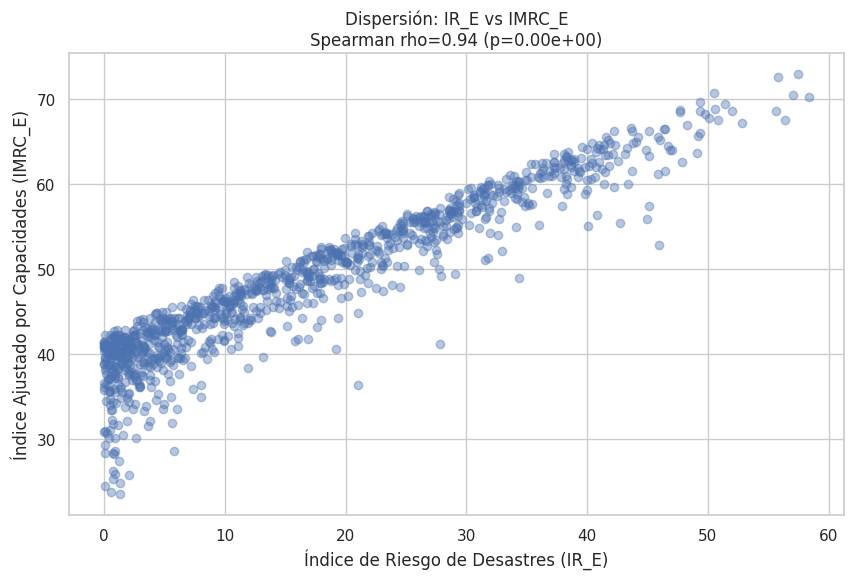

In [22]:
plt.figure(figsize=(10, 6))
sns.regplot(data=pdf, x='IR_E', y='IMRC_E', fit_reg=False, scatter_kws={'alpha': 0.4})
plt.title(f'Dispersión: IR_E vs IMRC_E\nSpearman rho={coef_ir_imrc:.2f} (p={p_ir_imrc:.2e})')
plt.xlabel('Índice de Riesgo de Desastres (IR_E)')
plt.ylabel('Índice Ajustado por Capacidades (IMRC_E)')
plt.show()

/tmp/ipykernel_2310512/1270065936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf_grupos, x='GRUPO_CAPACIDAD', y='IMRC_E', order=orden_grupos, palette='Set2')


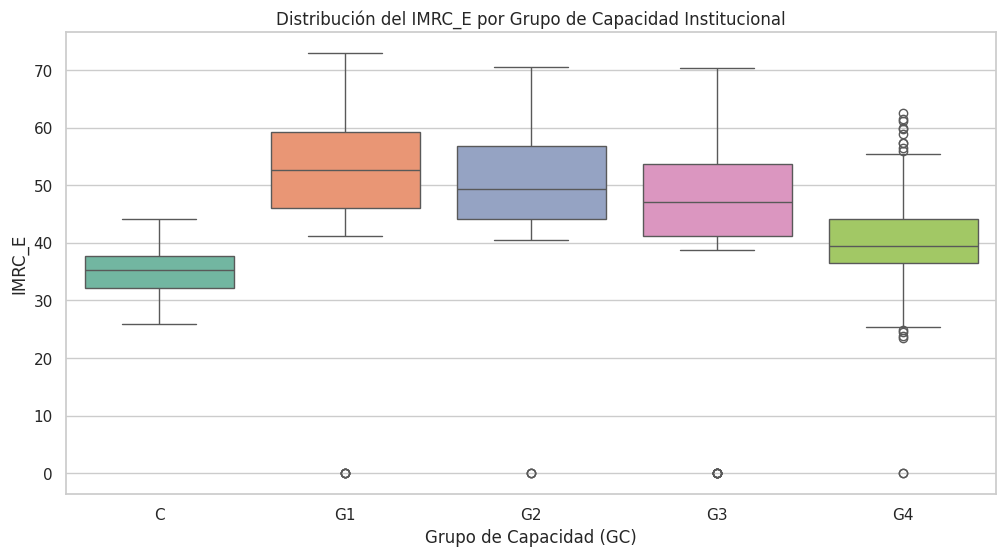

In [23]:
pdf_grupos = dfPy02.select('GRUPO_CAPACIDAD', 'IMRC_E').toPandas().dropna()

plt.figure(figsize=(12, 6))
orden_grupos = ['C', 'G1', 'G2', 'G3', 'G4']
sns.boxplot(data=pdf_grupos, x='GRUPO_CAPACIDAD', y='IMRC_E', order=orden_grupos, palette='Set2')
plt.title('Distribución del IMRC_E por Grupo de Capacidad Institucional')
plt.xlabel('Grupo de Capacidad (GC)')
plt.ylabel('IMRC_E')
plt.show()

Se evidencian tres correlaciones estadísticamente significativas y relevantes para el proyecto:

- **IR_E vs IMRC_E (rho = 0.94)**: correlación muy alta y positiva, lo esperado dado que el IMRC_E es una transformación del IR_E ajustada por capacidades. Los municipios con mayor riesgo de desastre mantienen índices ajustados elevados aun después de ponderar sus capacidades.
- **IC_E vs IMRC_E (rho = -0.56)**: correlación negativa moderada-alta. Los municipios con mayor capacidad institucional logran reducir su índice de riesgo ajustado, evidenciando el efecto protector de las capacidades de gestión.
- **IPM vs IR_E (rho = 0.37)**: correlación positiva moderada. Los municipios más pobres tienden a tener mayor riesgo de desastre, lo que sugiere una co-ocurrencia de vulnerabilidad social y riesgo físico que es relevante para el análisis conjunto con los resultados ICFES.

## **Reporte de calidad**

In [24]:
# Mostrar cantidad de nulos por columna (verificación formal)
dfPy02.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c)
               if t in ('double','float') else
               F.count(F.when(F.col(c).isNull(), c)).alias(c)
               for c, t in dfPy02.dtypes]).show()

+---+--------+------------+--------+---------+--------------+-----------------+------------------+------------------+----------------+---+----+------------------------+----------------+--------------------+-------------------+------------------------------+---------------+-----+-----+----+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
| ID|COD_DPTO|DEPARTAMENTO|DIVIPOLA|MUNICIPIO|TIPO_MUNICIPIO|AREA_AMENAZADA_HA|PCT_AREA_AMENAZADA|POBLACION_EXPUESTA|PCT_POB_EXPUESTA|IPM|IR_E|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|COMP_SOCIOECONOMICO|INGRESOS_TRIBUTARIOS_PERCAPITA|COMP_FINANCIERO|CMGRD|PMGRD|EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_E|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_E|
+---+--------+------------+--------+---------+--------------+-----------------+------------------+------------------+----------------+---+----+------------------------+----------------+-----

In [25]:
# Municipios con valores nulos en variables clave
muns_nulos = dfPy02.filter(
    F.col('IR_E').isNull() | F.isnan(F.col('IR_E')) |
    F.col('IMRC_E').isNull() | F.isnan(F.col('IMRC_E'))
)
print(f'Total de municipios con datos faltantes en IR_E o IMRC_E: {muns_nulos.count()}')
muns_nulos.select('MUNICIPIO', 'DEPARTAMENTO', 'TIPO_MUNICIPIO', 'IR_E', 'IMRC_E').show(truncate=False)

Total de municipios con datos faltantes en IR_E o IMRC_E: 21
+-------------------------------+----------------------------------------------------------+-----------------------+----+------+
|MUNICIPIO                      |DEPARTAMENTO                                              |TIPO_MUNICIPIO         |IR_E|IMRC_E|
+-------------------------------+----------------------------------------------------------+-----------------------+----+------+
|GRUPO DE CAPACIDAD -EXCESO (GC)|COMPONENTE GESTIÃ³N DEL RIESGO DE DESASTRES               |DISTANCIA EUCLADIANA   |NULL|NULL  |
|BARANOA                        |ATLÃNTICO                                                |MUNICIPIO              |NULL|0.0   |
|CANDELARIA                     |ATLÃNTICO                                                |MUNICIPIO              |NULL|0.0   |
|MALAMBO                        |ATLÃNTICO                                                |MUNICIPIO              |NULL|0.0   |
|PALMAR DE VARELA               |ATL

In [26]:
print(f'Total de registros en el dataset: {dfPy02.count()}')
print(f'Municipios de tipo distinto a Municipio: {dfPy02.filter(F.col("TIPO_MUNICIPIO") != "MUNICIPIO").count()}')

Total de registros en el dataset: 1122
Municipios de tipo distinto a Municipio: 20


Se reportan 21 registros con IR_E nulo, correspondientes principalmente a municipios sin datos de exposición poblacional. Adicionalmente, 18 registros son áreas no municipalizadas, 1 es una isla y 1 es una fila de encabezado residual del CSV, que por sus características no son comparables con los municipios regulares. Dado que estos registros representan menos del 2% del total y carecen de las variables de análisis principales, se decide eliminarlos en la fase de limpieza.

## **Planteamiento de preguntas investigativas**

1. ¿Existe una relación entre el nivel de riesgo de desastres por exceso de lluvias (IMRC_E) de un municipio y el rendimiento promedio de sus estudiantes en las pruebas ICFES?
2. ¿Los municipios con mayor vulnerabilidad social (IPM alto) y mayor riesgo de desastre presentan peores resultados educativos de forma sistemática?
3. ¿La capacidad institucional de un municipio para gestionar el riesgo (IC_E) está relacionada con mejores resultados en las pruebas ICFES, incluso controlando por el riesgo físico?
4. ¿Existen diferencias regionales (por departamento o grupo de capacidad) en la relación entre riesgo de desastre y rendimiento educativo que sugieran efectos heterogéneos en el territorio?

## **Limpieza, filtro y transformaciones iniciales**

In [27]:
# Filtrado: solo municipios con tipo 'MUNICIPIO' e IR_E no nulo
dfPy03 = dfPy02.filter(
    (F.col('TIPO_MUNICIPIO') == 'MUNICIPIO') &
    F.col('IR_E').isNotNull() & ~F.isnan(F.col('IR_E')) &
    F.col('IMRC_E').isNotNull() & ~F.isnan(F.col('IMRC_E'))
)

print(f'Registros antes de limpieza: {dfPy02.count()}')
print(f'Registros después de limpieza: {dfPy03.count()}')
print(f'Registros eliminados: {dfPy02.count() - dfPy03.count()}')

Registros antes de limpieza: 1122
Registros después de limpieza: 1084
Registros eliminados: 38


In [28]:
# Verificación final de nulos
print('Conteo de nulos tras limpieza:')
dfPy03.select(count_missings(dfPy03)).show()
print('Total de registros finales:', dfPy03.count())

Conteo de nulos tras limpieza:
+---+--------+------------+--------+---------+--------------+-----------------+------------------+------------------+----------------+---+----+------------------------+----------------+--------------------+-------------------+------------------------------+---------------+-----+-----+----+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
| ID|COD_DPTO|DEPARTAMENTO|DIVIPOLA|MUNICIPIO|TIPO_MUNICIPIO|AREA_AMENAZADA_HA|PCT_AREA_AMENAZADA|POBLACION_EXPUESTA|PCT_POB_EXPUESTA|IPM|IR_E|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|COMP_SOCIOECONOMICO|INGRESOS_TRIBUTARIOS_PERCAPITA|COMP_FINANCIERO|CMGRD|PMGRD|EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_E|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_E|
+---+--------+------------+--------+---------+--------------+-----------------+------------------+------------------+----------------+---+----+----------------

Dado los resultados del análisis exploratorio, se realizará una transformación logarítmica del IR_E e IMRC_E para los modelos que requieran supuestos de normalidad. Se filtran los municipios con IR_E = 0 o IMRC_E = 0 para esta versión transformada, conservando los datos originales para análisis sin supuestos paramétricos.

In [29]:
# Transformación logarítmica para modelos paramétricos
df_positivos = dfPy03.filter(
    (F.col('IR_E') > 0) & (F.col('IMRC_E') > 0)
)

df_log = df_positivos \
    .withColumn('log_IR_E', F.log(F.col('IR_E'))) \
    .withColumn('log_IMRC_E', F.log(F.col('IMRC_E')))

conteo_original = dfPy03.count()
conteo_final = df_log.count()

print(f'Registros originales: {conteo_original}')
print(f'Registros tras filtrar ceros: {conteo_final}')
print(f'Municipios descartados: {conteo_original - conteo_final}')

df_log.select('MUNICIPIO', 'IR_E', 'log_IR_E', 'IMRC_E', 'log_IMRC_E').show(5)

Registros originales: 1084
Registros tras filtrar ceros: 1078
Municipios descartados: 6
+-----------+-----+------------------+------+------------------+
|  MUNICIPIO| IR_E|          log_IR_E|IMRC_E|        log_IMRC_E|
+-----------+-----+------------------+------+------------------+
|  MEDELLÃN| 5.65|1.7316555451583495|  31.9| 3.462606009790799|
|  ABEJORRAL|18.18| 2.900322088749333|  51.0|3.9318256327243257|
|  ABRIAQUÃ| 28.7|3.3568971227655755|  56.6| 4.036008985209137|
|ALEJANDRÃA|12.16| 2.498151876538021|  44.0| 3.784189633918261|
|     AMAGÃ| 21.2| 3.054001181677967|  48.8|3.8877303128591016|
+-----------+-----+------------------+------+------------------+
only showing top 5 rows



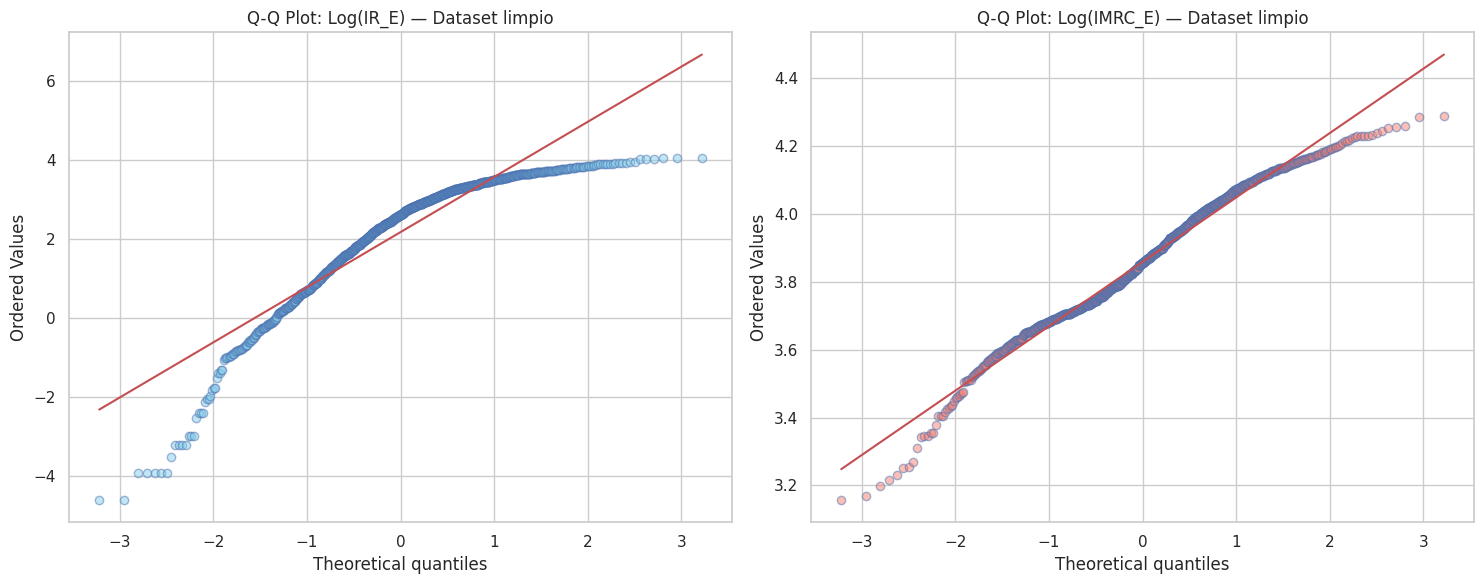

In [30]:
# QQ plots del dataset final transformado
pdf_log = df_log.select('log_IR_E', 'log_IMRC_E').toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

stats.probplot(pdf_log['log_IR_E'].dropna(), dist='norm', plot=ax1)
ax1.set_title('Q-Q Plot: Log(IR_E) — Dataset limpio')
ax1.get_lines()[0].set_markerfacecolor('skyblue')
ax1.get_lines()[0].set_alpha(0.5)

stats.probplot(pdf_log['log_IMRC_E'].dropna(), dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot: Log(IMRC_E) — Dataset limpio')
ax2.get_lines()[0].set_markerfacecolor('salmon')
ax2.get_lines()[0].set_alpha(0.5)

plt.tight_layout()
plt.show()

Los gráficos QQ plot del dataset limpio (sin municipios con riesgo cero) muestran una mejora significativa en la normalidad de las distribuciones transformadas con respecto a los datos originales. Aunque persisten algunas desviaciones en las colas extremas, la transformación logarítmica estabiliza la varianza y acerca las distribuciones al supuesto normal, lo que favorecerá la aplicación de modelos estadísticos paramétricos en las fases posteriores del proyecto.